## Data Preprocessing

In [2]:
import pandas as pd

In [3]:
dataframe = pd.read_csv('watson_healthcare_modified.csv')
dataframe.sample(4)

,EmployeeID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
594,1637745,35,No,Travel_Rarely,1258,Maternity,1,4,Life Sciences,1,...,3,80,0,7,0,3,2,2,2,2
1476,1432515,40,No,Travel_Frequently,791,Maternity,2,2,Medical,1,...,4,80,1,8,2,3,8,7,3,7
1524,1268816,40,No,Travel_Rarely,1202,Maternity,2,1,Medical,1,...,2,80,3,15,0,3,12,11,11,8
1571,1290256,30,No,Travel_Rarely,1427,Neurology,2,1,Medical,1,...,4,80,0,6,3,3,5,3,1,2


In [4]:
dataframe.shape

(1676, 35)

In [5]:
dataframe.select_dtypes(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,No,Travel_Rarely,Cardiology,Life Sciences,Female,Nurse,Single,Y,Yes
1,No,Travel_Frequently,Maternity,Life Sciences,Male,Other,Married,Y,No
2,Yes,Travel_Rarely,Maternity,Other,Male,Nurse,Single,Y,Yes
3,No,Travel_Frequently,Maternity,Life Sciences,Female,Other,Married,Y,Yes
4,No,Travel_Rarely,Maternity,Medical,Male,Nurse,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1671,Yes,Travel_Rarely,Neurology,Technical Degree,Male,Nurse,Single,Y,Yes
1672,No,Travel_Rarely,Cardiology,Marketing,Female,Nurse,Married,Y,Yes
1673,No,Travel_Rarely,Maternity,Life Sciences,Female,Other,Single,Y,No
1674,No,Travel_Rarely,Neurology,Life Sciences,Female,Therapist,Married,Y,No


In [6]:
dframe = dataframe.copy()
dframe.tail(5)
del dataframe # For original dataset safety

### Train/Test Splitting

In [7]:
y = dframe['Attrition']
X = dframe.drop('Attrition', axis=1)

In [8]:
(dframe.dtypes).unique()
del dframe # Save memory

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)

(1340, 34)

(336, 34)

(1340,)

(336,)

Encoding only the train sets to prevent data leakage

#### Attrition Mapping 

In [12]:
# mapping attrition columns to 1s and 0s
y_test = y_test.map({'Yes': 1, 'No': 0})
y_train = y_train.map({'Yes': 1, 'No': 0})
display(y_test.head(7))
display(y_train.tail(7))

1260    0
709     1
261     0
107     1
1639    0
228     0
1226    0
Name: Attrition, dtype: int64

382     0
428     0
735     0
1350    1
71      0
320     0
552     0
Name: Attrition, dtype: int64

#### Test set unwanted feature deletion

In [13]:
EmployeeID_safe = X_test['EmployeeID']
dropping_columns = ['EmployeeID', 'Over18', 'EmployeeCount', 'StandardHours']
X_test.drop(dropping_columns, axis=1, inplace=True)
X_test.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1260,42,Travel_Rarely,855,Maternity,12,3,Medical,2,Male,57,...,4,2,3,7,6,2,5,3,0,4
709,29,Travel_Rarely,906,Maternity,10,3,Life Sciences,4,Female,92,...,4,3,0,3,5,3,0,0,0,0
261,38,Non-Travel,1327,Cardiology,2,2,Life Sciences,4,Male,39,...,3,4,1,13,0,3,8,7,7,5
107,25,Travel_Rarely,240,Cardiology,5,3,Marketing,3,Male,46,...,3,4,0,6,1,3,6,4,0,3
1639,29,Travel_Rarely,352,Neurology,6,1,Medical,4,Male,87,...,3,4,0,1,3,3,1,0,0,0


#### Train set unwanted feature deletion

In [14]:
X_train.drop(dropping_columns, axis=1, inplace=True)
X_train.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
417,40,Travel_Rarely,1398,Cardiology,2,4,Life Sciences,3,Female,79,...,3,4,0,21,2,3,20,15,1,12
243,40,Travel_Rarely,1300,Maternity,24,2,Technical Degree,1,Male,62,...,3,1,2,9,3,3,9,8,4,7
1628,25,Travel_Rarely,622,Cardiology,13,1,Medical,2,Male,40,...,3,3,0,7,1,3,7,4,0,6
454,33,Travel_Rarely,922,Maternity,1,5,Medical,1,Female,95,...,3,3,1,10,2,3,6,1,0,5
1532,39,Travel_Frequently,505,Maternity,2,4,Technical Degree,3,Female,64,...,4,4,0,20,1,3,19,6,11,8


In [15]:
X_train.select_dtypes(include='int64')

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
417,40,1398,2,4,3,79,3,5,3,18041,...,3,4,0,21,2,3,20,15,1,12
243,40,1300,24,2,1,62,3,2,4,3319,...,3,1,2,9,3,3,9,8,4,7
1628,25,622,13,1,2,40,3,1,3,2096,...,3,3,0,7,1,3,7,4,0,6
454,33,922,1,5,1,95,4,4,3,16184,...,3,3,1,10,2,3,6,1,0,5
1532,39,505,2,4,3,64,3,3,3,10938,...,4,4,0,20,1,3,19,6,11,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,41,549,7,2,4,42,3,2,3,5003,...,3,2,0,8,6,3,2,2,2,1
1350,56,1162,24,2,1,97,3,1,4,2587,...,3,4,0,5,3,3,4,2,1,0
71,29,1328,2,3,3,76,3,1,2,2703,...,4,4,1,6,3,3,5,4,0,4
320,27,1377,2,3,4,74,3,2,3,4478,...,3,1,0,5,3,3,5,4,0,4


In [16]:
X_train.select_dtypes(include='object')

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
417,Travel_Rarely,Cardiology,Life Sciences,Female,Administrative,Married,No
243,Travel_Rarely,Maternity,Technical Degree,Male,Other,Divorced,No
1628,Travel_Rarely,Cardiology,Medical,Male,Other,Married,No
454,Travel_Rarely,Maternity,Medical,Female,Administrative,Divorced,No
1532,Travel_Frequently,Maternity,Technical Degree,Female,Other,Single,No
...,...,...,...,...,...,...,...
735,Travel_Rarely,Cardiology,Medical,Female,Therapist,Single,No
1350,Travel_Rarely,Neurology,Life Sciences,Male,Nurse,Single,No
71,Travel_Rarely,Maternity,Life Sciences,Male,Other,Married,No
320,Travel_Rarely,Cardiology,Life Sciences,Male,Nurse,Single,Yes


### Encoding Objects to Numerical Values

In [17]:
from sklearn.preprocessing import OneHotEncoder

In [18]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='error').set_output(transform='pandas')

#### Gender and Department encoding (ohe) and merging

In [19]:
enc_gender = ohe.fit_transform(X_train[['Gender']])
trans_gender = ohe.transform(X_test[['Gender']])
enc_department = ohe.fit_transform(X_train[['Department']])
trans_department = ohe.transform(X_test[['Department']])

In [20]:
display(enc_gender.sample(5))
display(trans_gender.sample(5))

,Gender_Female,Gender_Male
726,1.0,0.0
846,1.0,0.0
1547,0.0,1.0
379,1.0,0.0
1309,0.0,1.0


,Gender_Female,Gender_Male
532,0.0,1.0
1362,1.0,0.0
108,0.0,1.0
458,1.0,0.0
1097,1.0,0.0


In [21]:
display(enc_department.sample(4))
display(trans_department.sample(4))

,Department_Cardiology,Department_Maternity,Department_Neurology
992,0.0,1.0,0.0
571,1.0,0.0,0.0
209,0.0,1.0,0.0
982,0.0,1.0,0.0


,Department_Cardiology,Department_Maternity,Department_Neurology
1403,0.0,0.0,1.0
887,0.0,0.0,1.0
9,0.0,1.0,0.0
107,1.0,0.0,0.0


In [22]:
X_train = pd.concat([X_train, enc_department], axis=1).drop(columns=['Department'])
X_test = pd.concat([X_test, trans_department], axis=1).drop(columns=['Department'])
print(f'Test Set: {X_test.shape}')
display(X_test.sample(5))
print(f'Train Set: {X_train.shape}')
display(X_train.sample(5))

Test Set: (336, 32)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology
915,51,Travel_Frequently,237,9,3,Life Sciences,4,Male,83,3,...,31,5,2,29,10,11,10,1.0,0.0,0.0
753,32,Non-Travel,1109,29,4,Medical,4,Female,69,3,...,10,2,3,8,7,7,7,0.0,1.0,0.0
981,28,Travel_Rarely,736,26,3,Life Sciences,3,Male,48,2,...,5,0,3,5,3,0,4,1.0,0.0,0.0
911,55,Non-Travel,177,8,1,Medical,4,Male,37,2,...,34,3,3,33,9,15,0,0.0,1.0,0.0
734,48,Travel_Rarely,1355,4,4,Life Sciences,3,Male,78,2,...,27,3,3,15,11,4,8,0.0,1.0,0.0


Train Set: (1340, 32)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology
1659,26,Non-Travel,265,29,2,Medical,2,Male,79,1,...,7,6,3,2,2,2,2,1.0,0.0,0.0
1358,45,Travel_Frequently,1297,1,4,Medical,2,Male,44,3,...,12,3,3,4,2,0,3,0.0,0.0,1.0
315,43,Travel_Frequently,185,10,4,Life Sciences,3,Female,33,3,...,9,5,3,8,7,1,7,0.0,1.0,0.0
1548,38,Travel_Rarely,437,16,3,Life Sciences,2,Female,90,3,...,8,5,4,3,2,1,2,1.0,0.0,0.0
1148,28,Travel_Rarely,580,27,3,Medical,2,Female,39,1,...,6,5,2,5,3,0,0,0.0,1.0,0.0


In [23]:
X_train = pd.concat([X_train, enc_gender], axis=1).drop(columns=['Gender'])
X_test = pd.concat([X_test, trans_gender], axis=1).drop(columns=['Gender'])
print(f'Test Set: {X_test.shape}')
display(X_test.sample(5))
print(f'Train Set: {X_train.shape}')
display(X_train.sample(5))

Test Set: (336, 33)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
668,27,Travel_Rarely,618,4,3,Life Sciences,2,76,3,1,...,3,1,1,0,0,0.0,1.0,0.0,1.0,0.0
1440,56,Travel_Rarely,310,7,2,Technical Degree,4,72,3,1,...,1,10,9,9,8,0.0,0.0,1.0,0.0,1.0
280,53,Travel_Rarely,1070,3,4,Medical,3,45,3,4,...,2,5,3,1,3,0.0,0.0,1.0,0.0,1.0
447,40,Travel_Rarely,302,6,3,Life Sciences,2,75,3,4,...,3,20,6,5,13,0.0,0.0,1.0,1.0,0.0
261,38,Non-Travel,1327,2,2,Life Sciences,4,39,2,2,...,3,8,7,7,5,1.0,0.0,0.0,0.0,1.0


Train Set: (1340, 33)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
1082,31,Travel_Frequently,561,3,3,Life Sciences,4,33,3,1,...,1,7,2,7,7,0.0,1.0,0.0,1.0,0.0
819,34,Travel_Frequently,1003,2,2,Life Sciences,4,95,3,2,...,2,3,2,0,2,0.0,0.0,1.0,0.0,1.0
285,37,Travel_Rarely,1372,1,3,Life Sciences,4,42,3,1,...,3,17,12,5,7,0.0,1.0,0.0,1.0,0.0
31,44,Travel_Rarely,1459,10,4,Other,4,41,3,2,...,4,4,2,1,3,0.0,1.0,0.0,0.0,1.0
1162,44,Travel_Frequently,602,1,5,Human Resources,1,37,3,2,...,3,10,7,0,2,0.0,0.0,1.0,0.0,1.0


#### OverTime encoding (mapping to 1s and 0s)

In [24]:
X_train['OverTime']

417      No
243      No
1628     No
454      No
1532     No
       ... 
735      No
1350     No
71       No
320     Yes
552      No
Name: OverTime, Length: 1340, dtype: object

In [25]:
# yes = 1 | no = 0  
X_train['OverTime'] = X_train['OverTime'].map({'Yes': 1, 'No': 0})
X_test['OverTime'] = X_test['OverTime'].map({'Yes': 1, 'No': 0})

In [26]:
display(X_train.head(7))
display(X_test.head(7))

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
417,40,Travel_Rarely,1398,2,4,Life Sciences,3,79,3,5,...,3,20,15,1,12,1.0,0.0,0.0,1.0,0.0
243,40,Travel_Rarely,1300,24,2,Technical Degree,1,62,3,2,...,3,9,8,4,7,0.0,1.0,0.0,0.0,1.0
1628,25,Travel_Rarely,622,13,1,Medical,2,40,3,1,...,3,7,4,0,6,1.0,0.0,0.0,0.0,1.0
454,33,Travel_Rarely,922,1,5,Medical,1,95,4,4,...,3,6,1,0,5,0.0,1.0,0.0,1.0,0.0
1532,39,Travel_Frequently,505,2,4,Technical Degree,3,64,3,3,...,3,19,6,11,8,0.0,1.0,0.0,1.0,0.0
331,27,Non-Travel,210,1,1,Marketing,3,73,3,2,...,3,5,4,1,4,1.0,0.0,0.0,0.0,1.0
1110,32,Non-Travel,1200,1,4,Technical Degree,4,62,3,2,...,2,6,5,1,2,0.0,1.0,0.0,0.0,1.0


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
1260,42,Travel_Rarely,855,12,3,Medical,2,57,3,1,...,2,5,3,0,4,0.0,1.0,0.0,0.0,1.0
709,29,Travel_Rarely,906,10,3,Life Sciences,4,92,2,1,...,3,0,0,0,0,0.0,1.0,0.0,1.0,0.0
261,38,Non-Travel,1327,2,2,Life Sciences,4,39,2,2,...,3,8,7,7,5,1.0,0.0,0.0,0.0,1.0
107,25,Travel_Rarely,240,5,3,Marketing,3,46,2,2,...,3,6,4,0,3,1.0,0.0,0.0,0.0,1.0
1639,29,Travel_Rarely,352,6,1,Medical,4,87,2,1,...,3,1,0,0,0,0.0,0.0,1.0,0.0,1.0
228,35,Travel_Frequently,944,1,3,Marketing,3,92,3,3,...,4,10,7,0,8,1.0,0.0,0.0,1.0,0.0
1226,40,Travel_Rarely,369,8,2,Life Sciences,2,92,3,2,...,3,1,0,0,0,0.0,1.0,0.0,1.0,0.0


#### Ordinal encoding for BusinessTravel and MaritalStatus

In [27]:
travel_frequency = ['Non-Travel', 'Travel_Rarely', 'Travel_Frequently'] # 0.0 = Non-Travel, 1.0 = Travel_Rarely, 2.0 = Travel_Frequently
marital_status = ['Single','Married', 'Divorced']

In [28]:
from sklearn.preprocessing import OrdinalEncoder

In [29]:
oe_travel = OrdinalEncoder(categories=[travel_frequency])
oe_marital_status = OrdinalEncoder(categories= [marital_status])

In [30]:
X_train['BusinessTravel'] = oe_travel.fit_transform(X_train[['BusinessTravel']])
X_test['BusinessTravel'] = oe_travel.transform(X_test[['BusinessTravel']])

In [31]:
X_train['MaritalStatus'] = oe_marital_status.fit_transform(X_train[['MaritalStatus']])
X_test['MaritalStatus'] = oe_marital_status.transform(X_test[['MaritalStatus']])

In [32]:
display((X_train[['BusinessTravel','MaritalStatus']]).sample(7))
display((X_test[['BusinessTravel','MaritalStatus']]).sample(7))

,BusinessTravel,MaritalStatus
346,1.0,0.0
982,1.0,1.0
1558,1.0,1.0
1456,1.0,0.0
538,1.0,0.0
226,2.0,2.0
1259,2.0,1.0


,BusinessTravel,MaritalStatus
1319,1.0,2.0
1471,1.0,2.0
54,1.0,1.0
1113,1.0,1.0
1429,1.0,2.0
1592,2.0,2.0
733,1.0,0.0


In [33]:
max_len = max(len(col) for col in X_train.columns) # finds the length of the largest column name

for col in X_train.columns:
    print(f'{col:<{max_len}} = {X_train[col].nunique()}') # left aligns the column name

Age                      = 43
BusinessTravel           = 3
DailyRate                = 793
DistanceFromHome         = 29
Education                = 5
EducationField           = 6
EnvironmentSatisfaction  = 4
HourlyRate               = 71
JobInvolvement           = 4
JobLevel                 = 5
JobRole                  = 5
JobSatisfaction          = 4
MaritalStatus            = 3
MonthlyIncome            = 1134
MonthlyRate              = 1191
NumCompaniesWorked       = 10
OverTime                 = 2
PercentSalaryHike        = 15
PerformanceRating        = 2
RelationshipSatisfaction = 4
Shift                    = 4
TotalWorkingYears        = 40
TrainingTimesLastYear    = 7
WorkLifeBalance          = 4
YearsAtCompany           = 37
YearsInCurrentRole       = 19
YearsSinceLastPromotion  = 16
YearsWithCurrManager     = 18
Department_Cardiology    = 2
Department_Maternity     = 2
Department_Neurology     = 2
Gender_Female            = 2
Gender_Male              = 2


In [34]:
display((X_train['JobRole'] == 'Other').sum())
display((X_test['JobRole'] == 'Other').sum())

np.int64(434)

np.int64(100)

In [35]:
display((X_train['EducationField'] == 'Other').sum())
display((X_test['EducationField'] == 'Other').sum())

np.int64(75)

np.int64(13)

In [36]:
display((X_train['OverTime'] == 1).sum())
display((X_test['OverTime'] == 1).sum())

np.int64(386)

np.int64(90)

In [37]:
display((y_train == 1).sum())
display((y_test == 1).sum())

np.int64(159)

np.int64(40)

In [38]:
X_train.sample(7)

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
155,29,0.0,1496,1,1,Technical Degree,4,41,3,2,...,3,10,7,0,9,0.0,0.0,1.0,0.0,1.0
1305,38,1.0,723,2,4,Marketing,2,77,1,2,...,2,4,2,0,3,1.0,0.0,0.0,1.0,0.0
208,40,0.0,1151,9,5,Life Sciences,4,63,2,2,...,1,3,2,0,2,0.0,1.0,0.0,0.0,1.0
145,30,1.0,201,5,3,Technical Degree,4,84,3,1,...,3,3,2,2,2,0.0,1.0,0.0,1.0,0.0
1330,46,1.0,1254,10,3,Life Sciences,3,64,3,3,...,3,8,7,0,7,1.0,0.0,0.0,1.0,0.0
1569,42,2.0,748,9,2,Medical,1,74,3,1,...,3,12,9,5,8,0.0,0.0,1.0,1.0,0.0
1017,47,1.0,465,1,3,Technical Degree,1,74,3,1,...,2,6,5,1,2,0.0,1.0,0.0,0.0,1.0


In [39]:
X_test.sample(7)

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male
1265,53,0.0,661,1,4,Medical,1,60,2,4,...,2,3,2,0,2,0.0,0.0,1.0,1.0,0.0
593,58,1.0,286,2,4,Life Sciences,4,31,3,5,...,3,31,15,13,8,0.0,1.0,0.0,0.0,1.0
667,39,1.0,1122,6,3,Medical,4,70,3,1,...,1,2,2,2,2,0.0,1.0,0.0,0.0,1.0
798,50,2.0,959,1,4,Other,4,81,3,2,...,3,0,0,0,0,1.0,0.0,0.0,0.0,1.0
788,35,1.0,1204,4,3,Technical Degree,4,86,3,3,...,3,8,7,4,7,1.0,0.0,0.0,0.0,1.0
173,30,0.0,111,9,3,Medical,3,66,3,2,...,3,12,9,6,10,0.0,1.0,0.0,0.0,1.0
1639,29,1.0,352,6,1,Medical,4,87,2,1,...,3,1,0,0,0,0.0,0.0,1.0,0.0,1.0


#### JobRole and EducationField encoding (categorical mapping)

In [40]:
X_train['EducationField'] = X_train['EducationField'].map({'Other': 0, 'Life Sciences': 1, 'Medical': 2, 'Marketing': 3, 'Technical Degree': 4, 'Human Resources': 5})
X_train['is_other_JobRole'] = (X_train['JobRole'] == 'Other').astype(int)
X_train['JobRole'] = X_train['JobRole'].map({'Other': 0, 'Nurse': 1,'Therapist': 2, 'Administrative': 3, 'Admin': 4})

In [41]:
(X_train[['EducationField','is_other_JobRole','JobRole']]).sample(5)

,EducationField,is_other_JobRole,JobRole
41,1,0,1
894,1,0,1
1382,2,0,1
938,4,0,1
1143,1,0,2


In [42]:
X_test['EducationField'] = X_test['EducationField'].map({'Other': 0, 'Life Sciences': 1, 'Medical': 2, 'Marketing': 3, 'Technical Degree': 4, 'Human Resources': 5})
X_test['is_other_JobRole'] = (X_test['JobRole'] == 'Other').astype(int)
X_test['JobRole'] = X_test['JobRole'].map({'Other': 0, 'Nurse': 1,'Therapist': 2, 'Administrative': 3, 'Admin': 4})

In [43]:
(X_test[['EducationField','is_other_JobRole','JobRole']]).sample(5)

,EducationField,is_other_JobRole,JobRole
1334,2,1,0
1521,2,1,0
1212,2,1,0
1138,2,1,0
1543,4,0,2


In [44]:
X_train.dtypes

Age                           int64
BusinessTravel              float64
DailyRate                     int64
DistanceFromHome              int64
Education                     int64
EducationField                int64
EnvironmentSatisfaction       int64
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                       int64
JobSatisfaction               int64
MaritalStatus               float64
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
OverTime                      int64
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
Shift                         int64
TotalWorkingYears             int64
TrainingTimesLastYear         int64
WorkLifeBalance               int64
YearsAtCompany                int64
YearsInCurrentRole            int64
YearsSinceLastPromotion       int64
YearsWithCurrManager        

In [45]:
X_test.dtypes

Age                           int64
BusinessTravel              float64
DailyRate                     int64
DistanceFromHome              int64
Education                     int64
EducationField                int64
EnvironmentSatisfaction       int64
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                       int64
JobSatisfaction               int64
MaritalStatus               float64
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
OverTime                      int64
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
Shift                         int64
TotalWorkingYears             int64
TrainingTimesLastYear         int64
WorkLifeBalance               int64
YearsAtCompany                int64
YearsInCurrentRole            int64
YearsSinceLastPromotion       int64
YearsWithCurrManager        

In [46]:
# checking all the dtypes are equal in  train and test sets
display((X_train.dtypes == X_test.dtypes).any() )
display(y_train.dtype == y_test.dtype)

np.True_

True

In [47]:
display(X_train.shape)
display(X_test.shape)

(1340, 34)

(336, 34)

In [48]:
X_train.isna().any().any()

np.False_

In [49]:
X_test.isna().any().any()

np.False_

In [50]:
X_test.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education',
       'EducationField', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'Shift', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'Department_Cardiology', 'Department_Maternity', 'Department_Neurology',
       'Gender_Female', 'Gender_Male', 'is_other_JobRole'],
      dtype='object')

In [51]:
X_test.shape

(336, 34)

### Combining Train Cases to train_set and Test Cases to test_set

In [52]:
train_set = pd.concat([X_train, y_train], axis=1)
display(train_set.shape)
train_set.head()

(1340, 35)

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male,is_other_JobRole,Attrition
417,40,1.0,1398,2,4,1,3,79,3,5,...,15,1,12,1.0,0.0,0.0,1.0,0.0,0,0
243,40,1.0,1300,24,2,4,1,62,3,2,...,8,4,7,0.0,1.0,0.0,0.0,1.0,1,0
1628,25,1.0,622,13,1,2,2,40,3,1,...,4,0,6,1.0,0.0,0.0,0.0,1.0,1,0
454,33,1.0,922,1,5,2,1,95,4,4,...,1,0,5,0.0,1.0,0.0,1.0,0.0,0,0
1532,39,2.0,505,2,4,4,3,64,3,3,...,6,11,8,0.0,1.0,0.0,1.0,0.0,1,0


In [53]:
test_set = pd.concat([X_test, y_test], axis=1)
display(test_set.shape)
test_set.head()

(336, 35)

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male,is_other_JobRole,Attrition
1260,42,1.0,855,12,3,2,2,57,3,1,...,3,0,4,0.0,1.0,0.0,0.0,1.0,0,0
709,29,1.0,906,10,3,1,4,92,2,1,...,0,0,0,0.0,1.0,0.0,1.0,0.0,1,1
261,38,0.0,1327,2,2,1,4,39,2,2,...,7,7,5,1.0,0.0,0.0,0.0,1.0,0,0
107,25,1.0,240,5,3,3,3,46,2,2,...,4,0,3,1.0,0.0,0.0,0.0,1.0,0,1
1639,29,1.0,352,6,1,2,4,87,2,1,...,0,0,0,0.0,0.0,1.0,0.0,1.0,1,0


In [54]:
train_set.to_csv('train_set_datasheet.csv', index=False)
test_set.to_csv('test_set_datasheet.csv', index=False)

## Cross Validation

In [55]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [56]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### CV with Logistic Regression Model

In [57]:
import warnings
warnings.filterwarnings('ignore')

In [58]:
from sklearn.linear_model import LogisticRegression

In [59]:
lr = LogisticRegression(max_iter=500, random_state=42)

lr_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'LR CV ROC-AUC: {lr_scores}')
print(f'Mean ROC-AUC : {lr_scores.mean()}\n\nRounded ROC-AUC: {round(lr_scores.mean(), 3)} ')

LR CV ROC-AUC: [0.88335375 0.87182203 0.89141949 0.82719809 0.89764301]
Mean ROC-AUC : 0.8742872753897014

Rounded ROC-AUC: 0.874 


### CV with Random Forest Classifier

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'RF CV ROC-AUC: {rf_scores}')
print(f'Mean ROC-AUC : {rf_scores.mean()}\n\nRounded ROC-AUC: {round(rf_scores.mean(), 3)} ')

RF CV ROC-AUC: [0.9475296  0.9357786  0.94286282 0.93299788 0.92750265]
Mean ROC-AUC : 0.9373343106145018

Rounded ROC-AUC: 0.937 


### CV with Gradient Boosting Classifier

In [62]:
from sklearn.ensemble import GradientBoostingClassifier

In [63]:
gb = GradientBoostingClassifier(random_state=42)

gb_scores = cross_val_score(
    gb,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'GB CV ROC-AUC: {gb_scores}')
print(f'Mean ROC-AUC : {gb_scores.mean()}\n\nRounded ROC-AUC: {round(gb_scores.mean(), 3)} ')

GB CV ROC-AUC: [0.9508643  0.94637182 0.96305614 0.95762712 0.92412606]
Mean ROC-AUC : 0.9484090884841733

Rounded ROC-AUC: 0.948 


### CV with XGBoost 

In [64]:
from xgboost import XGBClassifier

In [65]:
xgb = XGBClassifier(
    n_estimators=200,        # not too large
    learning_rate=0.05,      # LOWER than default
    max_depth=3,             # very important (reduce)
    min_child_weight=5,      # prevents small leaf splits
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    eval_metric="logloss",
    random_state=42
)


xgb_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'GB CV ROC-AUC: {xgb_scores}')
print(f'Mean ROC-AUC : {xgb_scores.mean()}\n\nRounded ROC-AUC: {round(xgb_scores.mean(), 3)} ')

GB CV ROC-AUC: [0.96025589 0.95855403 0.95286017 0.95286017 0.94756356]
Mean ROC-AUC : 0.9544187620970627

Rounded ROC-AUC: 0.954 


In [66]:
# xgb = XGBClassifier(
#     n_estimators=200,
#     learning_rate=0.1,
#     max_depth=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric='logloss',
#     random_state=42
# )

In [67]:
# <model>  : <ROC-AUC value>
LR_Score = round(lr_scores.mean(), 3)
RF_Score = round(rf_scores.mean(), 3)
GB_Score = round(gb_scores.mean(), 3)
XGB_Score = round(xgb_scores.mean(), 3)

In [68]:
Scores = {'Logistic Regression': LR_Score, 'Random Forest Classifier': RF_Score, 'Gradient Boosting Classifier': GB_Score, 'XGBoost': XGB_Score}
models = {'Logistic Regression': lr, 'Random Forest Classifier': rf, 'Gradient Boosting Classifier': gb, 'XGBoost': xgb}

best_model_name = max(Scores, key=Scores.get)
best_model = models[best_model_name]

print(f'The Best Model for Training is {best_model_name}')

The Best Model for Training is XGBoost


## Training Model

In [69]:
best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [70]:
from sklearn.metrics import roc_auc_score

In [71]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]
print(f'Test set ROC-AUC: {round(roc_auc_score(y_test, y_test_proba), 3)}')

Test set ROC-AUC: 0.927


#### Probability Class Splitting

In [72]:
def risk_pred(p):
    if (p < 0.25):
        return 'most likely to stay'
    elif (p >= 0.25 and p < 0.50):
        return 'likely to stay'
    elif (p >= 0.50 and p < 0.75):
        return 'likely to leave'
    else:
        return 'most likely to leave'

In [73]:
# dataset with EmployeeID
EmployeeID_dataset = pd.concat([EmployeeID_safe, X_test], axis=1)
del EmployeeID_safe
display(EmployeeID_dataset.shape)
EmployeeID_dataset.head()

(336, 35)

,EmployeeID,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male,is_other_JobRole
1260,1628396,42,1.0,855,12,3,2,2,57,3,...,5,3,0,4,0.0,1.0,0.0,0.0,1.0,0
709,1658398,29,1.0,906,10,3,1,4,92,2,...,0,0,0,0,0.0,1.0,0.0,1.0,0.0,1
261,1520532,38,0.0,1327,2,2,1,4,39,2,...,8,7,7,5,1.0,0.0,0.0,0.0,1.0,0
107,1410589,25,1.0,240,5,3,3,3,46,2,...,6,4,0,3,1.0,0.0,0.0,0.0,1.0,0
1639,1309082,29,1.0,352,6,1,2,4,87,2,...,1,0,0,0,0.0,0.0,1.0,0.0,1.0,1


In [74]:
# turning prpobability to binary
y_pred_binary = (y_test_proba >= 0.5).astype(int)

In [75]:
results = pd.DataFrame({
    'PersonID': EmployeeID_dataset['EmployeeID'],   
    'Attrition_Probability': y_test_proba,
    'Binary_Prediction': y_pred_binary,
    'Predicted_Risk': [risk_pred(p) for p in y_test_proba],
    'Actual_Attrition': y_test.values
})

In [76]:
results.sample(10)

,PersonID,Attrition_Probability,Binary_Prediction,Predicted_Risk,Actual_Attrition
809,1789769,0.009772,0,most likely to stay,0
1411,1863212,0.116184,0,most likely to stay,0
915,1426682,0.010185,0,most likely to stay,0
732,1559236,0.165201,0,most likely to stay,0
820,1377897,0.011065,0,most likely to stay,0
1530,1252790,0.011470,0,most likely to stay,0
289,1124932,0.007170,0,most likely to stay,0
1586,1709085,0.025689,0,most likely to stay,0
1281,1692699,0.002911,0,most likely to stay,0
43,1680993,0.011534,0,most likely to stay,0


In [77]:
from sklearn.metrics import accuracy_score

In [78]:
accuracy = accuracy_score(y_test, y_pred_binary)
print(f'Accuracy: {round(accuracy, 3)}')

Accuracy: 0.932


### Model Evaluation

In [79]:
from sklearn.metrics import classification_report, confusion_matrix

In [80]:
print(f'\n=== {best_model_name} Evaluation ===\n')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_binary))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_binary))


=== XGBoost Evaluation ===

Confusion Matrix:
[[293   3]
 [ 20  20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       296
           1       0.87      0.50      0.63        40

    accuracy                           0.93       336
   macro avg       0.90      0.74      0.80       336
weighted avg       0.93      0.93      0.92       336



## Avoiding Overfitting With Undersampling

In [81]:
from imblearn.under_sampling import RandomUnderSampler

In [82]:
rus = RandomUnderSampler(random_state=42)

In [83]:
# fitting the train set to the under sampler
X_res_train, y_res_train = rus.fit_resample(X_train, y_train)

## Cross Validation for Resampled data

In [84]:
del best_model # save memory

### Resampled CV Logistic Regression

In [85]:
lr_scores = cross_val_score(
    lr,
    X_res_train,
    y_res_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'LR CV ROC-AUC: {lr_scores}')
print(f'Mean ROC-AUC : {lr_scores.mean()}\n\nRounded ROC-AUC: {round(lr_scores.mean(), 3)} ')

LR CV ROC-AUC: [0.86035156 0.93359375 0.80078125 0.84778226 0.86189516]
Mean ROC-AUC : 0.8608807963709676

Rounded ROC-AUC: 0.861 


### Resampled CV Random Forest Classifier

In [86]:
rf_scores = cross_val_score(
    rf,
    X_res_train,
    y_res_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'RF CV ROC-AUC: {rf_scores}')
print(f'Mean ROC-AUC : {rf_scores.mean()}\n\nRounded ROC-AUC: {round(rf_scores.mean(), 3)} ')

RF CV ROC-AUC: [0.92333984 0.93945312 0.94580078 0.89516129 0.94808468]
Mean ROC-AUC : 0.930367943548387

Rounded ROC-AUC: 0.93 


### Resampled CV Gradient Boosting Classifier

In [87]:
gb_scores = cross_val_score(
    gb,
    X_res_train,
    y_res_train,
    cv=cv,
    scoring='roc_auc'
)


print(f'GB CV ROC-AUC: {gb_scores}')
print(f'Mean ROC-AUC : {gb_scores.mean()}\n\nRounded ROC-AUC: {round(gb_scores.mean(), 3)} ')

GB CV ROC-AUC: [0.9140625  0.93945312 0.9375     0.88104839 0.94354839]
Mean ROC-AUC : 0.9231224798387097

Rounded ROC-AUC: 0.923 


### Resampled CV XGBoost

In [88]:
xgb = XGBClassifier(
    n_estimators=200,        # not too large
    learning_rate=0.05,      # LOWER than default
    max_depth=3,             # very important (reduce)
    min_child_weight=5,      # prevents small leaf splits
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    eval_metric="logloss",
    random_state=42
)

xgb_scores = cross_val_score(
    xgb,
    X_res_train,
    y_res_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'GB CV ROC-AUC: {gb_scores}')
print(f'Mean ROC-AUC : {gb_scores.mean()}\n\nRounded ROC-AUC: {round(gb_scores.mean(), 3)} ')

GB CV ROC-AUC: [0.9140625  0.93945312 0.9375     0.88104839 0.94354839]
Mean ROC-AUC : 0.9231224798387097

Rounded ROC-AUC: 0.923 


In [89]:
LR_Score = round(lr_scores.mean(), 3)
RF_Score = round(rf_scores.mean(), 3)
GB_Score = round(gb_scores.mean(), 3)
XGB_Score = round(xgb_scores.mean(), 3)

In [90]:
Scores = {'Logistic Regression': LR_Score, 'Random Forest Classifier': RF_Score, 'Gradient Boosting Classifier': GB_Score, 'XGBoost': XGB_Score}
models = {'Logistic Regression': lr, 'Random Forest Classifier': rf, 'Gradient Boosting Classifier': gb, 'XGBoost': xgb}

best_model_name = max(Scores, key=Scores.get)
best_resampled_model = models[best_model_name]

print(f'The Best Model for Training is {best_model_name}')

The Best Model for Training is XGBoost


In [91]:
best_resampled_model.fit(X_res_train, y_res_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [92]:
y_test_proba = best_resampled_model.predict_proba(X_test)[:, 1]
print(f'Test set ROC-AUC: {round(roc_auc_score(y_test, y_test_proba), 3)}')

Test set ROC-AUC: 0.928


In [93]:
results.sample(10)

,PersonID,Attrition_Probability,Binary_Prediction,Predicted_Risk,Actual_Attrition
458,1566630,0.133338,0,most likely to stay,0
190,1173311,0.001835,0,most likely to stay,0
515,1136352,0.003633,0,most likely to stay,0
1579,1157111,0.013520,0,most likely to stay,0
780,1221286,0.004265,0,most likely to stay,0
167,1138977,0.003219,0,most likely to stay,0
630,1341422,0.246471,0,most likely to stay,0
317,1202360,0.020147,0,most likely to stay,0
301,1464566,0.741537,1,likely to leave,1
1172,1505937,0.002818,0,most likely to stay,0


In [94]:
y_pred_binary = (y_test_proba >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred_binary)

print(f'Accuracy: {round(accuracy, 3)}')

Accuracy: 0.881


In [95]:
print(f'\n=== {best_model_name} Evaluation with Resampled Train-Set ===\n')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_binary))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_binary))


=== XGBoost Evaluation with Resampled Train-Set ===

Confusion Matrix:
[[262  34]
 [  6  34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       296
           1       0.50      0.85      0.63        40

    accuracy                           0.88       336
   macro avg       0.74      0.87      0.78       336
weighted avg       0.92      0.88      0.89       336



In [96]:
# Train (RESAMPLED)
y_train_res_proba = best_resampled_model.predict_proba(X_res_train)[:, 1]
train_auc = roc_auc_score(y_res_train, y_train_res_proba)

# Test (ORIGINAL, untouched)
y_test_proba = best_resampled_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Train ROC-AUC (resampled):", round(train_auc, 3))
print("Test ROC-AUC:", round(test_auc, 3))

Train ROC-AUC (resampled): 0.991
Test ROC-AUC: 0.928


## Using scale_pos_weight (No RandomUnderSampler)

In [97]:
pos_sum = (y_train == 1).sum()
neg_sum = (y_train == 0).sum()
display(pos_sum)
display(neg_sum)

np.int64(159)

np.int64(1181)

In [98]:
proportion = neg_sum / pos_sum
display(proportion)

np.float64(7.427672955974843)

In [99]:
xgb = XGBClassifier(
    n_estimators=200,        
    eta=0.05,      
    max_depth=3,             
    min_child_weight=5, 
    gamma=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,           
    reg_lambda=1.0,          
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=proportion
)

xgb_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'GB CV ROC-AUC: {gb_scores}')
print(f'Mean ROC-AUC : {gb_scores.mean()}\n\nRounded ROC-AUC: {round(gb_scores.mean(), 3)} ')

GB CV ROC-AUC: [0.9140625  0.93945312 0.9375     0.88104839 0.94354839]
Mean ROC-AUC : 0.9231224798387097

Rounded ROC-AUC: 0.923 


In [100]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [101]:
y_test_proba = xgb.predict_proba(X_test)[:, 1]
print(f'Test set ROC-AUC: {round(roc_auc_score(y_test, y_test_proba), 3)}')

Test set ROC-AUC: 0.916


In [102]:
y_pred_binary = (y_test_proba >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred_binary)

print(f'Accuracy: {round(accuracy, 3)}')

Accuracy: 0.899


In [103]:
print(f'\n=== {best_model_name} Evaluation with Resampled Train-Set ===\n')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_binary))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_binary))


=== XGBoost Evaluation with Resampled Train-Set ===

Confusion Matrix:
[[276  20]
 [ 14  26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       296
           1       0.57      0.65      0.60        40

    accuracy                           0.90       336
   macro avg       0.76      0.79      0.77       336
weighted avg       0.91      0.90      0.90       336



In [104]:
y_train_proba = xgb.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, y_train_proba)

y_test_proba = xgb.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Train ROC-AUC :", round(train_auc, 3))
print("Test ROC-AUC  :", round(test_auc, 3))

Train ROC-AUC : 0.997
Test ROC-AUC  : 0.916


#### Using Quantile Method

In [113]:
Probabilities = pd.DataFrame({'probability': y_test_proba})
Probabilities.head()

,probability
0,0.039787
1,0.983836
2,0.002329
3,0.719832
4,0.481837


In [126]:
Probabilities['Risk_Profile'] = pd.qcut(
    Probabilities['probability'],
    q = [0, 0.50 ,0.75, 0.90, 1],
    labels = ['Most likely to stay', 'Likely to stay', 'Likely to leave', 'Most likely to leave']
)

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

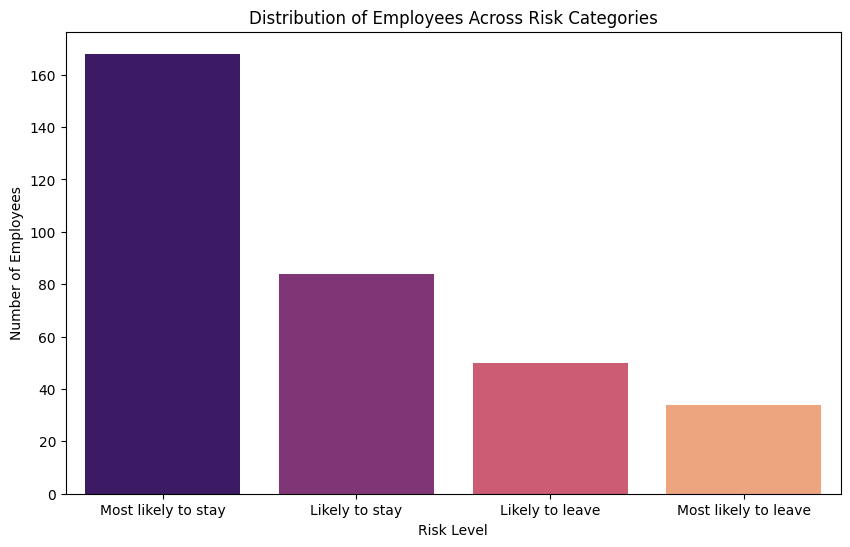

In [119]:
plt.figure(figsize=(10, 6))
sns.countplot(data=Probabilities, x='risk_profile', palette='magma')
plt.title('Distribution of Employees Across Risk Categories')
plt.xlabel('Risk Level')
plt.ylabel('Number of Employees')
plt.show()

In [128]:
new_results = pd.DataFrame({
    'PersonID': EmployeeID_dataset['EmployeeID'],   
    'Attrition_Probability': y_test_proba,
    'Risk_Profile': Probabilities['Risk_Profile'],
    'Actual_Attrition': y_test.values
})

In [129]:
new_results.head(20)

,PersonID,Attrition_Probability,Risk_Profile,Actual_Attrition
1260,1628396,0.039787,Likely to stay,0
709,1658398,0.983836,Most likely to leave,1
261,1520532,0.002329,Most likely to stay,0
107,1410589,0.719832,Most likely to leave,1
1639,1309082,0.481837,Likely to leave,0
228,1278690,0.008697,Most likely to stay,0
1226,1417199,0.014358,Most likely to stay,0
653,1457833,0.604474,Likely to leave,0
453,1780761,0.010472,Most likely to stay,0
1204,1270535,0.189449,Likely to stay,0


In [136]:
# Convert probabilities to binary predictions (using 0.5 as a baseline)
y_pred = (y_test_proba >= 0.5).astype(int)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.90

Detailed Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       296
           1       0.57      0.65      0.60        40

    accuracy                           0.90       336
   macro avg       0.76      0.79      0.77       336
weighted avg       0.91      0.90      0.90       336

